#Objective: Build a regression model that predicts product sales based on advertising spend across different media channels (TV, Radio, Newspaper)
-----------------------------------------------------------------------------------------------------------------------------------------

#Importing Necessary Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model creration and training&testing libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#LOADING THE DATA SET

In [2]:
# Load dataset
df = pd.read_csv("Advertising.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
#checking the last five raws
df.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [4]:
#descriptive analysis
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [5]:
#checking the dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
#checking the number of raws and columns
df.shape

(200, 5)

In [7]:
#checking for duplicate 
df.duplicated().sum()

0

In [8]:
#checking the missing values
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [9]:
#checking number of columns
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [10]:
#Removing the unnnamed column 
df = df.drop(columns=["Unnamed: 0"])

In [11]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


#EDA

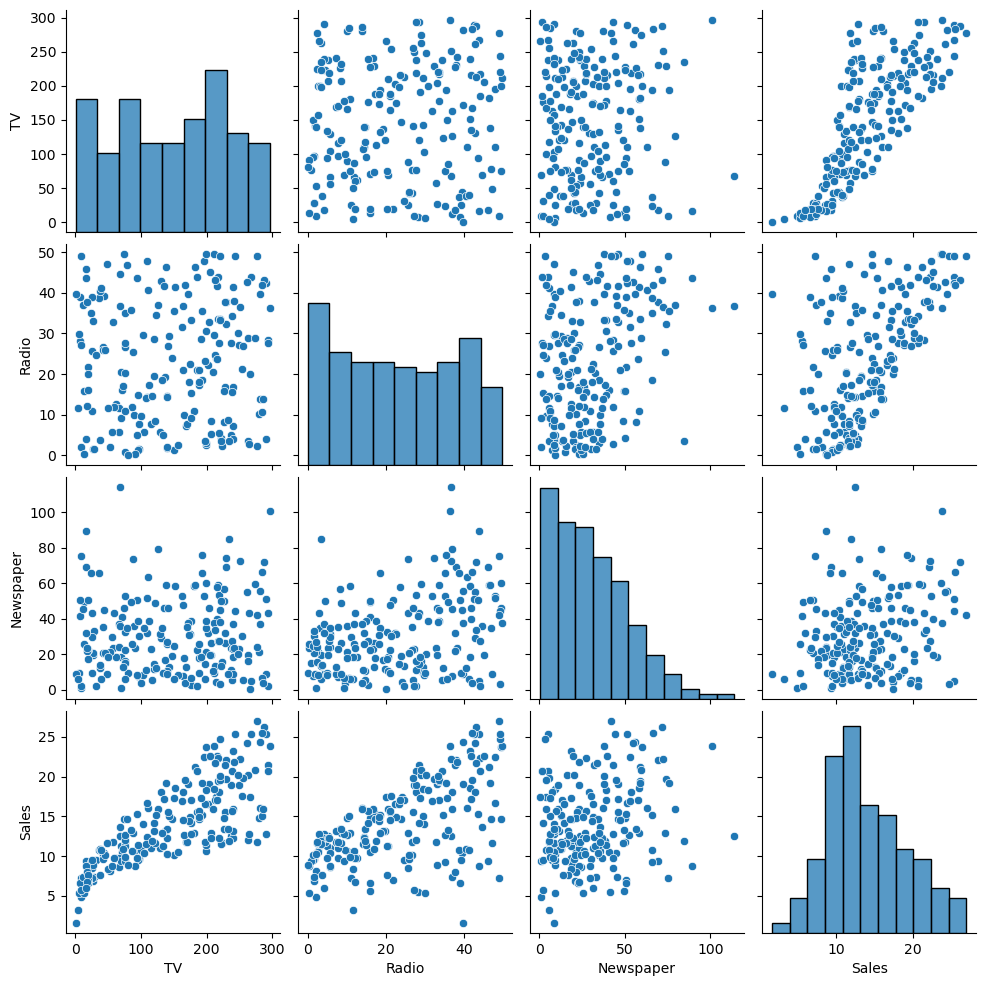

In [12]:
#Visualizing using pairplot
sns.pairplot(df)

plt.show()

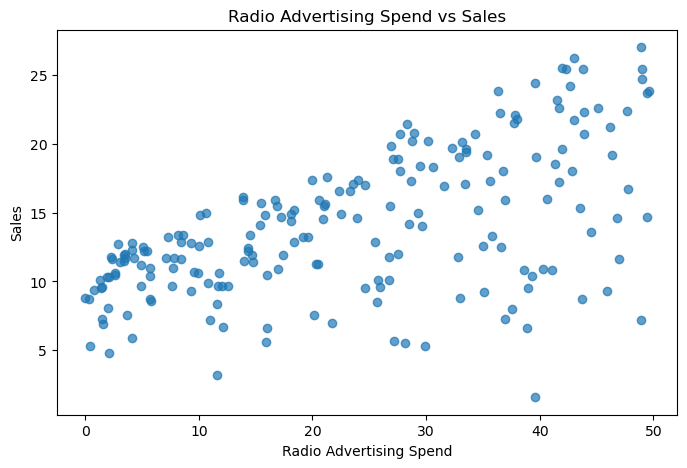

In [13]:
#Scatter Plot — Radio vs Sales
plt.figure(figsize=(8, 5))

plt.scatter(df["Radio"], df["Sales"], alpha=0.7)

plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")
plt.title("Radio Advertising Spend vs Sales")

plt.show()

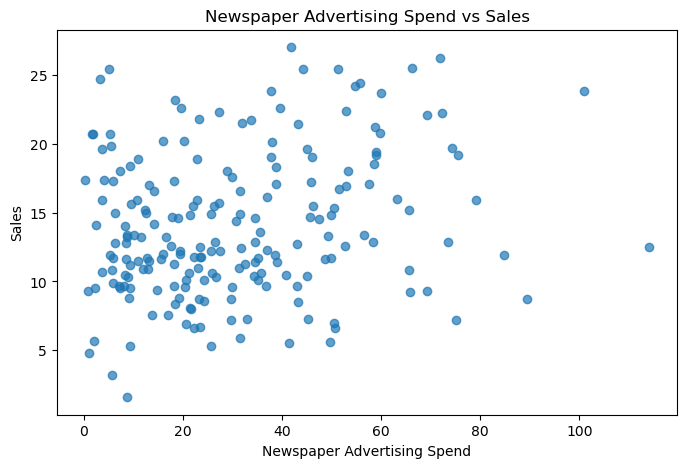

In [14]:
#Scatter Plot — Newspaper vs Sale
plt.figure(figsize=(8, 5))

plt.scatter(df["Newspaper"], df["Sales"], alpha=0.7)

plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")
plt.title("Newspaper Advertising Spend vs Sales")

plt.show()

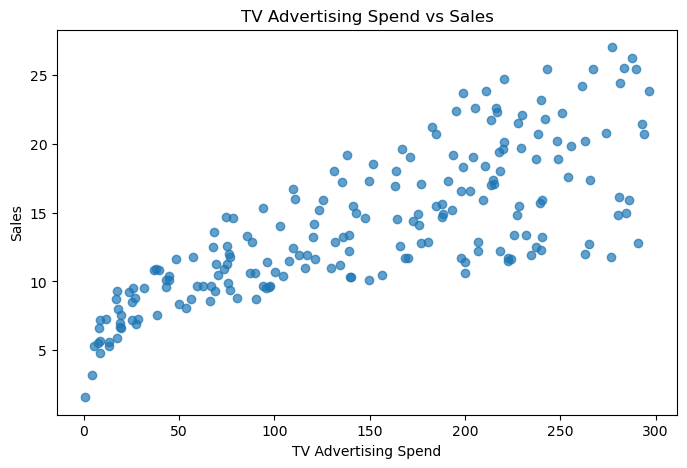

In [15]:
#Scatter Plot — TV vs Sales
plt.figure(figsize=(8, 5))

plt.scatter(df["TV"], df["Sales"], alpha=0.7)

plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.title("TV Advertising Spend vs Sales")

plt.show()

In [16]:
#Checking a correlation
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


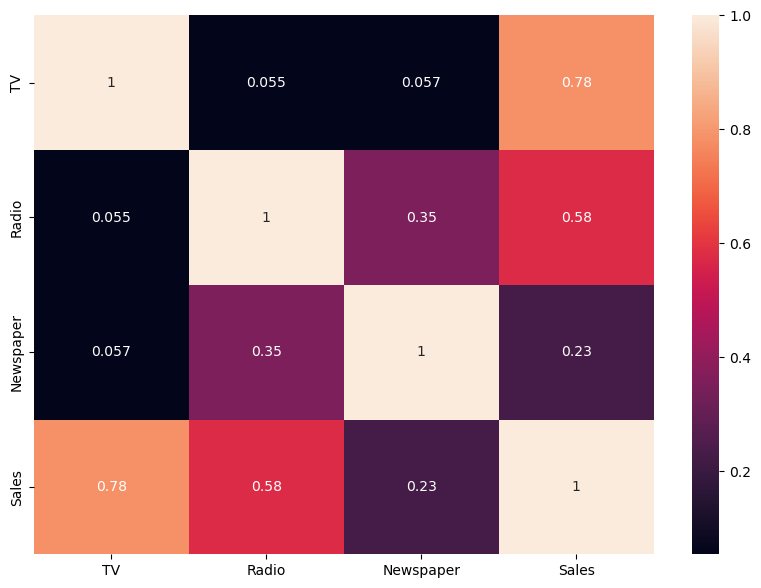

In [17]:
#visualizing correlation using a heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True)
plt.show()

#TRAINING/TESTING AND SPLITING THE DATA 

In [18]:
#defining independent variables and dependent variables
x= df[["TV", "Radio", "Newspaper"]]
y= df["Sales"]

In [19]:
#splitting my data into 80% and 20%
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2, random_state=42)

In [20]:
#checking the size 
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


#Linear Regression Model

In [21]:
#creating the model
lr = LinearRegression()

In [22]:
#training the model
lr.fit(x_train, y_train)

LinearRegression()

In [23]:
#making the prediction
y_pred = lr.predict(x_test)

In [24]:
#Linear Regression Coefficients
print("Intercept:", lr.intercept_)

print("TV coefficient:", lr.coef_[0])
print("Radio coefficient:", lr.coef_[1])
print("Newspaper coefficient:", lr.coef_[2])

Intercept: 2.979067338122631
TV coefficient: 0.04472951746871629
Radio coefficient: 0.18919505423437677
Newspaper coefficient: 0.0027611143413671657


#The intercept represent the predicted sales when TV,RADIO, and Newspaper adverstising spending are all zero.So when the is no advert expendenture on all categories then the predicted sales would be approximately 2.98 units.So when we hold Rodio and Newspaper spending constant and increase TV advert spending by 1 unit the estimation increas it will b by 0.0447 unit increase in sales.If we hold TV and Newspaper spending constant and increas Radio advert spending by 1 unit is estimated by 0.1892 unit increase in sales.Based on the Linear Regression Coefficient Radio has the highest Coeffiecient.  


#EVALUATING LINEARREGRESSION MODEL USING MAE,RMSE,R2-SCORE

In [25]:
#doing the evaluation
mae_lr = mean_absolute_error(y_test, y_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr = r2_score(y_test, y_pred)

#Displaying the results
print("Linear Regression Results")
print("-------------------------")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

Linear Regression Results
-------------------------
MAE: 1.4607567168117601
RMSE: 1.781599661533451
R² Score: 0.8994380241009119


#The Linear Regression model achieved an MAE of 1.46, an RMSE of 1.78, and an R² score of 0.8994. The R² score indicates that approximately 89.94% of the variation in product sales is explained by TV, Radio, and Newspaper advertising expenditure. The model's predictions differ from actual sales by approximately 1.46 units on average based on MAE. Overall, the Linear Regression model provides a strong baseline for predicting sales.

#Training the Second Model — Random Forest

In [26]:
#Creating the model
rf = RandomForestRegressor(n_estimators=200, random_state=42)

In [27]:
#training the model
rf.fit(x_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [28]:
#making prediction
y_pred = rf.predict(x_test)

In [29]:
#Evaluating the model
mae_rf = mean_absolute_error(y_test, y_pred)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred))

r2_rf = r2_score(y_test, y_pred)

#printing the results 
print("Random Forest Results")
print("---------------------")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
---------------------
MAE: 0.6287125000000021
RMSE: 0.7572349907723515
R² Score: 0.9818333477552758


#random forest regressor archived the higher R2-score and lower errors compared to Linear Regression becouse RandomForest Regressor captures non linear relationships,interactions between TV,RADIO, and NEWSPAPER and also more complex patterns in the data.Thats is why it has achieved the higher r2 score and lower errors.  

#Model comparison

In [31]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        1.4607567,
        0.6287125
    ],
    "RMSE": [
        1.7815997,
        0.7572350
    ],
    "R² Score": [
        0.8994380,
        0.9818333
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.628713,0.757235,0.981833


#Conclusion

#Random Forest Regressor is the best model in all three evaluation matrics compared to LinearRegression.Random Forest achieved an MAE of 0.629, RMSE of 0.757,and R2 score of 0.9818.this means the model's predictions differ from the actual sales by 0.63 units on avarage and that of approximately 98.18% of the variation in sales.

#Residual plot

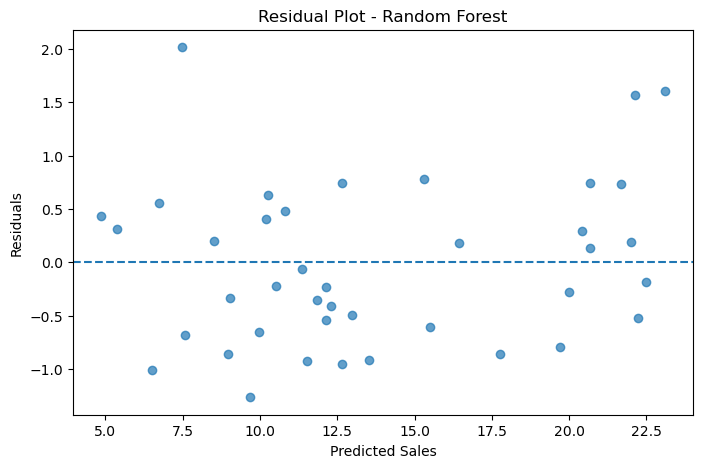

In [33]:
#Plotting the residual
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")

plt.show()

#CONCLUSION
The residuals appear to be reasonably randomly distributed around zero, with no strong systematic pattern. This suggests that the Random Forest model is capturing the main relationships between advertising expenditure and sales. Although some prediction errors are present, there is no obvious structure in the residuals indicating a major problem with the model.